# Plot CSDA acquisitions summary info

+ Calendar heatmap
+ Progress dashboard example
+ Comprehensive acquisition progress plots

| Author | Affiliation | Date |
| ---------------- | ---------------- | ---------------- |
| Paul Montesano, PhD | Innovation Lab ; NASA Goddard Space Flight Center | Feb. 2025 |

In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(RColorBrewer)
library(sf)
library(lubridate)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message in CPL_gdal_init():
“GDAL Error 1: /panfs/ccds02/app/modules/jupyter/ilab/R-kernel/lib/R/modules//../../libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)”
Warning message in CPL_gdal_init():
“GDAL Error 1: /panfs/ccds02/app/modules/jupyter/ilab/R-kernel/lib/R/modules//../../libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)”
Warning message in CPL_gdal_init():
“GDAL Error 1: /panfs/ccds02/app/modules/jupyter/ilab/R-kernel/lib/R/modules//../../libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)”
Warning message in CPL_gdal_init():
“GDAL Erro

In [2]:
# Function 2: Calendar heatmap
plot_acquisition_heatmap <- function(footprint_df, 
                                     title = 'CSDA Tasking Orders: Image Acquisition Heatmap',
                                     LEGEND_TITLE = "Number of acquisitions",
                                     bin_by = 'day',  # 'day', 'week', 'month', or numeric (e.g., 5, 10)
                                     bin_days = NULL) {  # Alternative: specify number of days directly
      
    # Determine binning (allow numeric input or bin_days parameter)
    if (!is.null(bin_days)) {
      bin_interval <- bin_days
    } else if (is.numeric(bin_by)) {
      bin_interval <- bin_by
    } else {
      bin_interval <- bin_by  # 'day', 'week', 'month'
    }
    
    # Filter to MS only
    df_ms <- footprint_df %>%
      filter(image_type != 'P') %>%
      mutate(
        year = year(date),
        month = month(date),
        day = day(date)
      )
    
    # Create binning based on parameter
    if (is.numeric(bin_interval)) {
      # Custom day interval (5-day, 10-day, etc.)
      df_ms <- df_ms %>%
        mutate(
          yday = yday(date),
          # Bin by n-day intervals
          day_bin = ceiling(yday / bin_interval),
          # Calculate bin start date
          bin_start_yday = (day_bin - 1) * bin_interval + 1,
          bin_start_date = as.Date(paste(year, bin_start_yday), format = "%Y %j"),
          # Create date without year for plotting
          date_no_year = as.Date(paste("2000", format(bin_start_date, "%m-%d"), sep = "-")),
          time_label = paste0('D', sprintf('%03d', bin_start_yday))
        )
      x_breaks <- paste(bin_interval * 2, "days")
      x_labels <- "%b %d"
      tile_width <- bin_interval  # KEY: Set tile width to bin interval
      
    } else if (bin_interval == 'week') {
      df_ms <- df_ms %>%
        mutate(
          week = isoweek(date),
          week_start = floor_date(date, 'week', week_start = 1),
          date_no_year = as.Date(paste("2000", format(week_start, "%m-%d"), sep = "-")),
          time_label = paste0('W', sprintf('%02d', week))
        )
      x_breaks <- "2 weeks"
      x_labels <- "%b %d"
      tile_width <- 7
      
    } else if (bin_interval == 'month') {
      df_ms <- df_ms %>%
        mutate(
          month_start = floor_date(date, 'month'),
          date_no_year = as.Date(paste("2000", format(month_start, "%m-%d"), sep = "-")),
          time_label = month.abb[month]
        )
      x_breaks <- "1 month"
      x_labels <- "%b"
      tile_width <- 30
      
    } else {  # day (original behavior)
      df_ms <- df_ms %>%
        mutate(
          month_day = format(date, "%m-%d"),
          date_no_year = as.Date(paste("2000", format(date, "%m-%d"), sep = "-")),
          time_label = month_day
        )
      x_breaks <- "1 month"
      x_labels <- "%m-%d"
      tile_width <- 1
    }
    
    # Create sensor label
    df_ms <- df_ms %>%
      mutate(sensor_label = paste(affiliation, sensor, sep = ' - '))
    
    # Aggregate by year, date_no_year, and sensor
    daily_counts <- df_ms %>%
      group_by(year, date_no_year, sensor_label, affiliation) %>%
      summarise(count = n(), .groups = 'drop')

    # Sort descending by year in the data before plotting
    daily_counts <- daily_counts %>%
      mutate(year = factor(year, levels = sort(unique(year), decreasing = TRUE)))
      
    # Get max count for scale
    max_count <- max(daily_counts$count)
    
    # Create plot - KEY CHANGE: Add width parameter to geom_tile
    p <- ggplot(daily_counts, aes(x = date_no_year, y = sensor_label, fill = count)) +
      geom_tile(width = tile_width, linewidth = 0.5) +  # Added width parameter
      scale_fill_viridis_c(
        option = "plasma",
        name = LEGEND_TITLE,
        limits = c(1, max_count),
        breaks = scales::pretty_breaks(n = 4),
        labels = scales::label_number(accuracy = 1)
      ) +
      scale_color_viridis_c(
        option = "plasma",
        name = LEGEND_TITLE,
        limits = c(1, max_count),
        breaks = scales::pretty_breaks(n = 4),
        labels = scales::label_number(accuracy = 1)
      ) +
      labs(
        title = title, subtitle = paste0('as of: ', Sys.Date()),
        x = NULL,
        y = NULL,
      ) +
      scale_x_date(
        date_breaks = x_breaks,
        date_labels = x_labels,
        expand = c(0, 0),
          position = "top",
         #sec.axis = dup_axis()  # Duplicate axis on top
      ) +
      theme_bw(base_size = 22) +
      guides(fill = guide_colorbar(
        title.position = "top",
        title.hjust = 0.5,
        barwidth = 15,
        barheight = 1
      )) +
      theme(
        #axis.text.x = element_text(angle = 45, hjust = 1),
          axis.text.x = element_text(angle = 45, hjust = 0),
        axis.text.y = element_text(size = 13),
        plot.title = element_text(face = "bold", size = 30, hjust = 0),
        axis.title = element_text(face = "bold", size = 12),
        legend.position = "top",
        legend.direction = "horizontal",
        plot.margin = margin(10, 10, 10, 10)
      ) +
      facet_grid(year ~ ., scales='free_y', space = 'free_y')
      
    return(p)
}

In [3]:
footprint_df = st_read('/explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_ACQUISITIONS_latest.gpkg') %>% as.data.frame()

Reading layer `footprints_CSDA_eval_ACQUISITIONS_2026-03-05' from data source 
  `/panfs/ccds02/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_ACQUISITIONS_latest.gpkg' 
  using driver `GPKG'
Simple feature collection with 795 features and 20 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -174.8357 ymin: -51.73878 xmax: 145.3509 ymax: 63.96054
Geodetic CRS:  WGS 84


In [26]:
z = footprint_df %>% filter(constellation == 'Legion' & image_type != 'P' & Site_Primary != 'Not CSDA Eval Site')
dim(z)

[1] 52 21

## Calendar heatmap from footprints

#### (all data downloaded - might be non CSDA eval data in here)

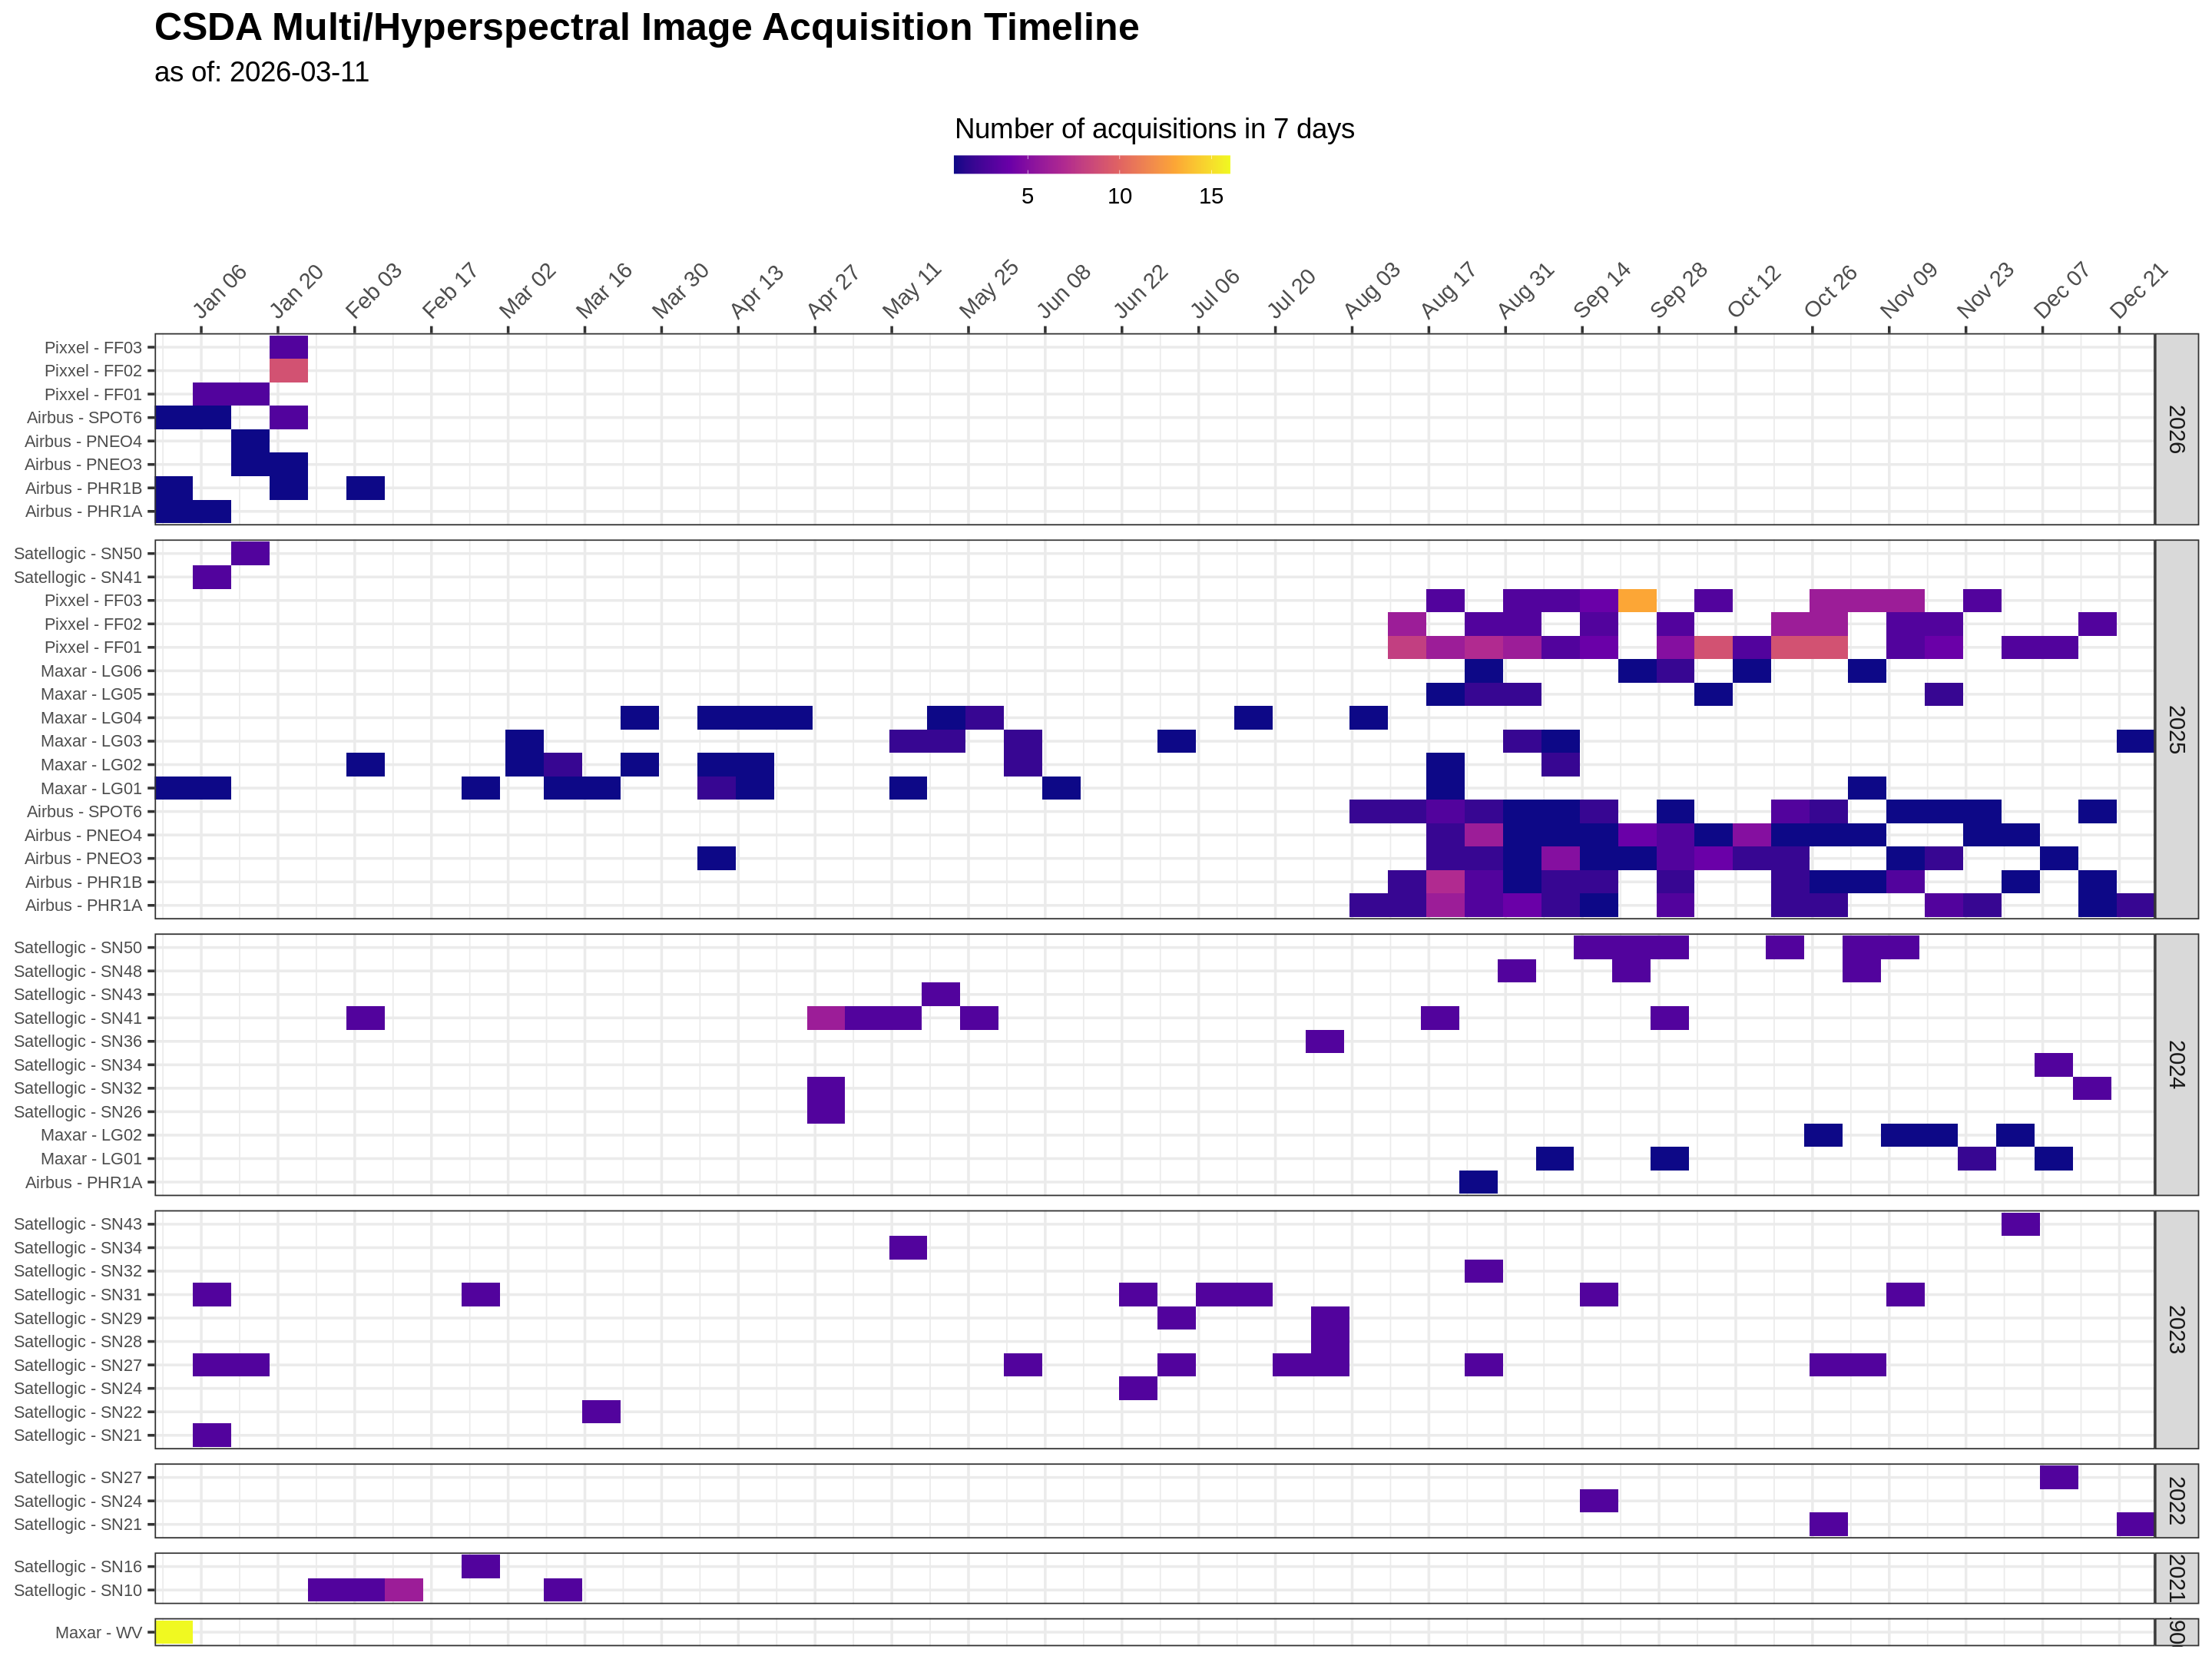

In [4]:
options(repr.plot.width = 24, repr.plot.height = 18)

# Usage example:
# Make sure your date column is in Date format
footprint_df$date <- as.Date(footprint_df$date)

# Create heatmap
N_DAYS = 7
heatmap_plot <- plot_acquisition_heatmap(footprint_df, bin_days = N_DAYS, title = 'CSDA Multi/Hyperspectral Image Acquisition Timeline', LEGEND_TITLE = paste0("Number of acquisitions in ",N_DAYS," days"))
heatmap_plot

# # Save plots
# ggsave("acquisition_timeline_gantt.png", gantt_plot, width = 16, height = 10, dpi = 300)
# ggsave("acquisition_heatmap.png", heatmap_plot, width = 16, height = 10, dpi = 300)

## Summary of CSDA Eval data

#### this should exclude 'Not CSDA Eval Site'

In [22]:
final_summary = read.csv('/explore/nobackup/projects/CSDA_eval/summaries/CSDA_eval_sites_footprint_summary_MS_latest.csv')
dim(final_summary)

[1] 94 10

In [28]:
sum((final_summary %>% filter(constellation == 'Legion'))$acquisition_count)

[1] 52

In [21]:
z = summary_df %>% filter(constellation == 'Legion')
sum(z$Acquisitions_Completed)
sum(z$Acquisitions_Remaining)


[1] 52

[1] 9

## Progress dashboard

In [8]:
library(ggplot2)
library(patchwork)
library(dplyr)
library(tidyr)
library(scales)
library(viridis)

# Text
base_size = 20

# Prepare data
summary_df <- final_summary %>%
  mutate(
    Acquisitions_Completed = acquisition_count,
    Acquisitions_Remaining = ifelse(is.na(Acquisitions.Remaining), 0, Acquisitions.Remaining),
    Acquisitions_Requested = ifelse(is.na(Acquisitions.Requested), 0, Acquisitions.Requested),
    Progress_Pct = ifelse(Acquisitions_Requested > 0, 
                          (Acquisitions_Completed / Acquisitions_Requested) * 100, 
                          100)
  )

# Color palette
affiliation_colors <- c("Airbus" = "#0072B2", "Maxar" = "#E69F00", "Pixxel" = 'yellow',
                        "Planet" = "#009E73", "Unknown" = "#999999")

# 1. Overall progress by affiliation
p1 <- summary_df %>%
  group_by(affiliation) %>%
  summarise(
    Completed = sum(Acquisitions_Completed),
    Remaining = sum(Acquisitions_Remaining),
    Requested = sum(Acquisitions_Requested)
  ) %>%
  pivot_longer(cols = c(Completed, Remaining), 
               names_to = "Status", 
               values_to = "Count") %>%
  ggplot(aes(x = reorder(affiliation, -Requested), y = Count, fill = Status)) +
  geom_col(position = "stack", width = 0.7) +
  geom_text(aes(label = Count), position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 5) +
  scale_fill_manual(values = c("Completed" = "#2ecc71", "Remaining" = "#e74c3c")) +
  labs(title = "Acquisition Progress by Affiliation",
       x = NULL, y = "Number of Acquisitions") +
  theme_minimal(base_size = base_size+1) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, size = 16),
    legend.position = "top",
    legend.title = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(face = "bold", size = 16)
  )

# 2. Top sites needing acquisitions
p2 <- summary_df %>%
  filter(Site != "") %>%
  group_by(Site) %>%
  summarise(
    Total_Remaining = sum(Acquisitions_Remaining),
    Total_Requested = sum(Acquisitions_Requested),
    Total_Completed = sum(Acquisitions_Completed),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Remaining)) %>%
  #head(15) %>%
  ggplot(aes(x = reorder(Site, Total_Remaining), y = Total_Remaining)) +
  geom_col(aes(fill = Total_Remaining), width = 0.7) +
  geom_text(aes(label = Total_Remaining), hjust = 1.25, fontface = "bold", size = 6, color='white') +
  #scale_fill_gradient(low = "#f39c12", high = "#e74c3c", guide = "none") +
  scale_fill_viridis(option = 'turbo', name = "Remaining\nAcquisitions") +
  coord_flip() +
  labs(title = "Sites with Most Acquisitions Remaining",
       x = NULL, y = "Acquisitions Remaining") +
  theme_minimal(base_size = base_size) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, size = 14),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(size = 16, face = "bold")
  )

# 3. Detailed heatmap by site and sensor
p3 <- summary_df %>%
  filter(Site != "") %>%
  mutate(constellation_label = paste0(constellation, " (", affiliation, ")")) %>%
  ggplot(aes(x = constellation_label, y = Site, fill = Acquisitions_Remaining)) +
  geom_tile(color = "white", size = 0.5) +
  geom_text(aes(label = ifelse(Acquisitions_Remaining >=0, Acquisitions_Remaining, "")),
            color = "white", fontface = "bold", size = 5) +
  # scale_fill_gradient2(low = "#2ecc71", mid = "#f39c12", high = "#e74c3c",
  #                      midpoint = median(summary_df$Acquisitions_Remaining[summary_df$Acquisitions_Remaining > 0], na.rm = TRUE),
  #                      name = "Remaining\nAcquisitions") +
  scale_fill_viridis(option = 'turbo', name = "Remaining\nAcquisitions") +
  labs(title = "Acquisitions Remaining by Site and Constellation",
       x = NULL, y = NULL) +
  theme_minimal(base_size = base_size-1) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),
    axis.text.y = element_text(size = 16),
    panel.grid = element_blank(),
    legend.position = "right"
  )



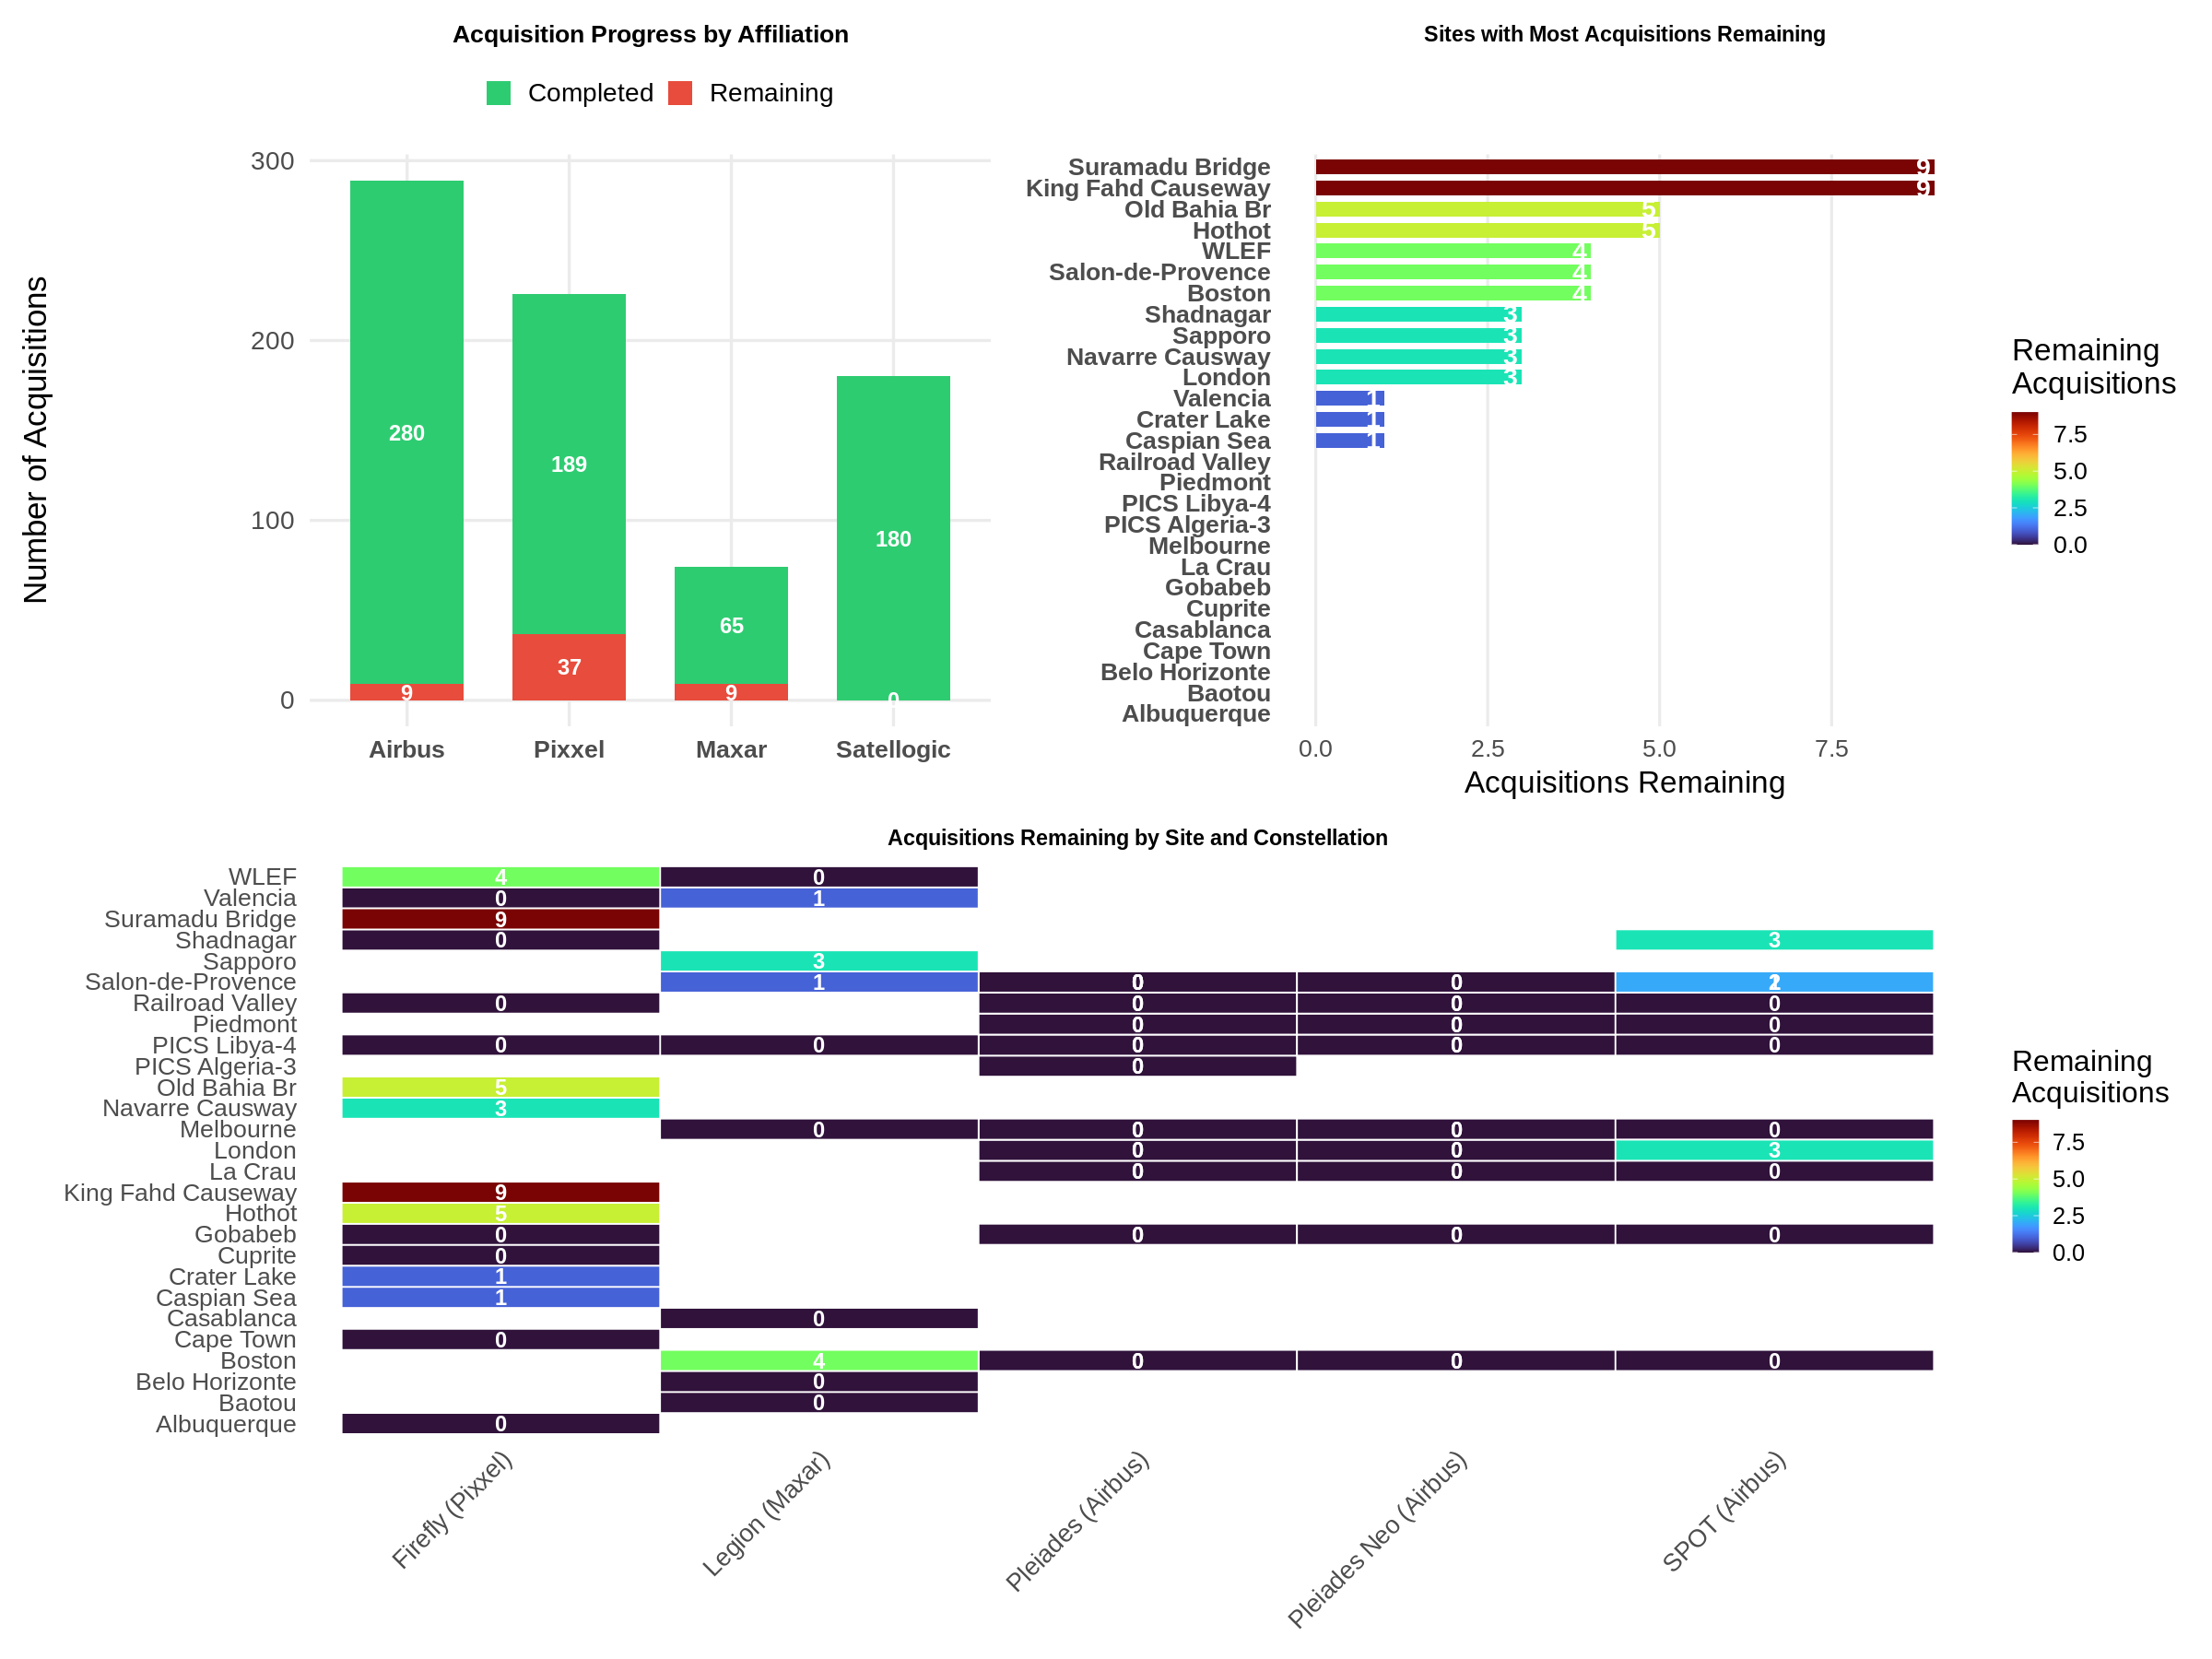

In [9]:
options(repr.plot.width = 20, repr.plot.height = 15)
p_progress_dashboard = (p1 | p2) /( p3 )
p_progress_dashboard

## Comprehensive Acquisition Progress Plots

In [11]:
# Prepare data
plot_data_tmp = final_summary %>% 
  mutate(Site_Primary = ifelse(is.na(Site_Primary) | Site_Primary == "", Site, Site_Primary)) %>%
  group_by(Site_Primary, affiliation) %>%
  summarise(
    Requested = sum(Acquisitions.Requested, na.rm = TRUE),
    Remaining = sum(Acquisitions.Remaining, na.rm = TRUE),
    Completed = sum(acquisition_count, na.rm = TRUE),
    .groups = "drop"
  )

# Create data for Completed and Remaining bars
plot_data <- plot_data_tmp %>%
  filter(Site_Primary != "") %>%
  pivot_longer(cols = c(Completed, Remaining), 
               names_to = "Status", 
               values_to = "Count") %>%
  mutate(Status = factor(Status, levels = c("Remaining", "Completed"))) %>%
  arrange(Site_Primary)

# Create separate data for the "Requested" outline
plot_data_target <- plot_data_tmp %>%
  filter(Site_Primary != "") %>%
  select(Site_Primary, affiliation, Requested) %>%
  arrange(Site_Primary)


# Create label data with positions stacked vertically to the right of target bar
label_data <- plot_data_tmp %>%
  filter(Site_Primary != "") %>%
  select(Site_Primary, affiliation, Requested, Completed, Remaining) %>%
  # Calculate the rightmost position (max of target or actual bars)
  mutate(
    total_actual = Completed + Remaining,
    max_bar_position = pmax(Requested, total_actual, na.rm = TRUE)  # Use the larger value
  ) %>%
  pivot_longer(cols = c(Requested, Completed, Remaining),
               names_to = "Type",
               values_to = "Value") %>%
  mutate(
    Type = factor(Type, levels = c("Requested", "Completed", "Remaining")),
    label_color = case_when(
      Type == "Requested" ~ "black",
      Type == "Completed" ~ "#2ecc71",
      Type == "Remaining" ~ "#e74c3c"
    ),
    # Stack labels vertically, starting from the rightmost bar position
    label_y = max_bar_position + 10 + (as.numeric(Type) - 1) * 10  # Adjust spacing as needed
  ) %>%
  arrange(Site_Primary, Type)

# Create plot
p_progress = ggplot() +
  # FIRST: Plot colored progress bars (stacked)
  geom_col(data = plot_data,
           aes(x = Site_Primary, y = Count, fill = Status),
           width = 0.7) +
  # SECOND: Plot black outline for "Requested" target (on top)
  geom_col(data = plot_data_target,
           aes(x = Site_Primary, y = Requested),
           fill = NA,
           color = "black",
           width = 0.7,
           size = 1.5) +
  # THIRD: Add labels with white background and color-matched text
  geom_label(data = label_data,
             aes(x = Site_Primary, 
                 y = label_y,        # Use calculated position
                 label = Value, 
                 color = Type),
             hjust = 0,              # Left-align the labels
             vjust = 0.5,            # Center vertically
             fontface = "bold", 
             size = 4,
             fill = "white",         # White background
             label.padding = unit(0.25, "lines"),
             label.size = 0.5) +     # Border around label
  # Define fill colors for bars
  scale_fill_manual(values = c("Completed" = "#2ecc71", "Remaining" = "#e74c3c"),
                    name = NULL) +
  # Define color scale for labels (matching the bars/outline)
  scale_color_manual(values = c("Requested" = "black",
                                 "Completed" = "#2ecc71", 
                                 "Remaining" = "#e74c3c"),
                     guide = "none") +  # Hide this legend
  labs(title = "CSDA Multi/Hyperspectral Image Acquisition Progress by Site",
       subtitle = "Black outline = Requested target | Green = Completed | Red = Remaining",
       x = NULL,
       y = "Number of Acquisitions",
      caption= 'Note: acquisitions need to fall within 10 km of site lat/lon to satisfy request') +
  theme_minimal(base_size = 30) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, size = 40),
    plot.subtitle = element_text(hjust = 0.5, size = 16, color = "gray40"),
    legend.position = "top",
    axis.text = element_text(angle = 0, hjust = 1, face = "bold", size = 16),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  facet_wrap(~affiliation, ncol = 4) + 
  coord_flip()


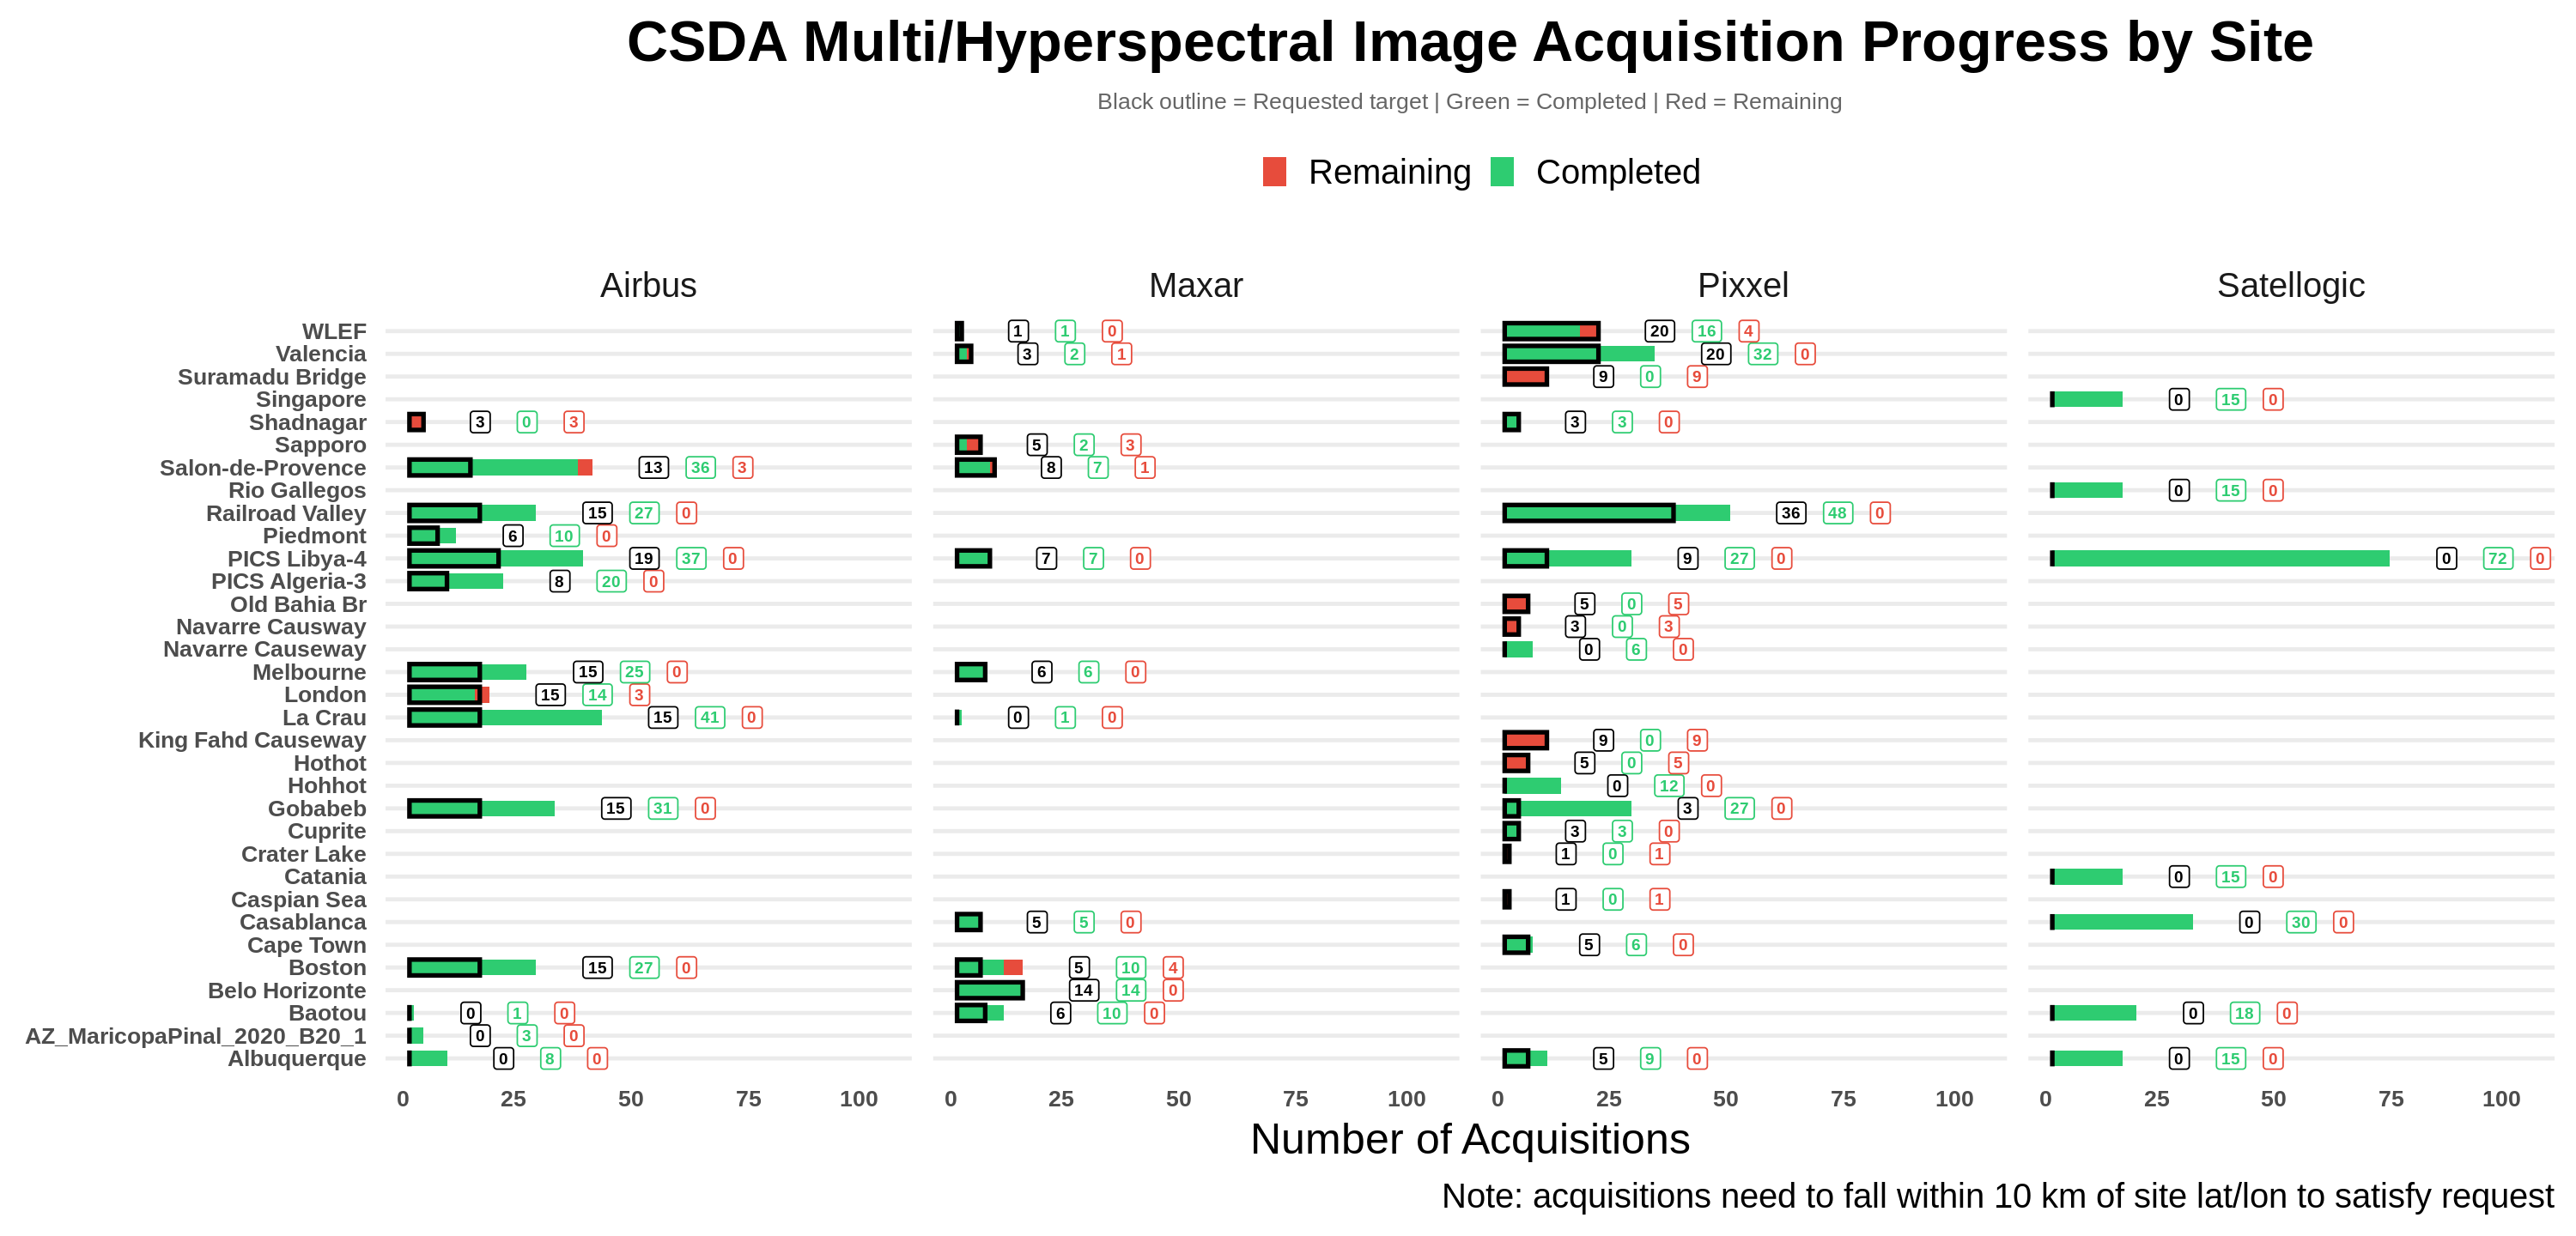

In [12]:
options(repr.plot.width = 25, repr.plot.height = 12)

p_progress

In [13]:
# Prepare data
plot_data_tmp = final_summary %>% 
  mutate(Site_Primary = ifelse(is.na(Site_Primary) | Site_Primary == "", Site, Site_Primary)) %>%
  group_by(Site_Primary, affiliation, constellation) %>%
  summarise(
    Requested = sum(Acquisitions.Requested, na.rm = TRUE),
    Remaining = sum(Acquisitions.Remaining, na.rm = TRUE),
    Completed = sum(acquisition_count, na.rm = TRUE),
    .groups = "drop"
  )

# Create data for Completed and Remaining bars
plot_data <- plot_data_tmp %>%
  filter(Site_Primary != "") %>%
  pivot_longer(cols = c(Completed, Remaining), 
               names_to = "Status", 
               values_to = "Count") %>%
  mutate(Status = factor(Status, levels = c("Remaining", "Completed"))) %>%
  arrange(Site_Primary)

# Create separate data for the "Requested" outline
plot_data_target <- plot_data_tmp %>%
  filter(Site_Primary != "") %>%
  select(Site_Primary, affiliation, constellation, Requested) %>%
  arrange(Site_Primary)


# Create label data with positions stacked vertically to the right of target bar
label_data <- plot_data_tmp %>%
  filter(Site_Primary != "") %>%
  select(Site_Primary, affiliation, constellation, Requested, Completed, Remaining) %>%
  # Calculate the rightmost position (max of target or actual bars)
  mutate(
    total_actual = Completed + Remaining,
    max_bar_position = pmax(Requested, total_actual, na.rm = TRUE)  # Use the larger value
  ) %>%
  pivot_longer(cols = c(Requested, Completed, Remaining),
               names_to = "Type",
               values_to = "Value") %>%
  # Filter out Remaining labels where Value is 0 or NA
  filter(!(Type == "Remaining" & (is.na(Value) | Value == 0))) %>%
  mutate(
    Type = factor(Type, levels = c("Requested", "Completed", "Remaining")),
    label_color = case_when(
      Type == "Requested" ~ "black",
      Type == "Completed" ~ "#2ecc71",
      Type == "Remaining" ~ "#e74c3c"
    ),
    # Stack labels vertically, starting from the rightmost bar position
    label_y = max_bar_position + 10 + (as.numeric(Type) - 1) * 10  # Adjust spacing as needed
  ) %>%
  arrange(Site_Primary, Type)

# Create plot
p_progress_v2 = ggplot() +
  # FIRST: Plot colored progress bars (stacked)
  geom_col(data = plot_data,
           aes(x = Site_Primary, y = Count, fill = Status),
           width = 0.7) +
  # SECOND: Plot black outline for "Requested" target (on top)
  geom_col(data = plot_data_target,
           aes(x = Site_Primary, y = Requested),
           fill = NA,
           color = "black",
           width = 0.7,
           size = 1.5) +
  # THIRD: Add labels with white background and color-matched text
  geom_label(data = label_data,
             aes(x = Site_Primary, 
                 y = label_y,        # Use calculated position
                 label = Value, 
                 color = Type),
             hjust = 1,              # Left-align the labels
             vjust = 0.5,            # Center vertically
             fontface = "bold", 
             size = 4,
             fill = "white",         # White background
             label.padding = unit(0.2, "lines"),
             label.size = 0.5) +     # Border around label
  # Define fill colors for bars
  scale_fill_manual(values = c("Completed" = "#2ecc71", "Remaining" = "#e74c3c"),
                    name = NULL) +
  # Define color scale for labels (matching the bars/outline)
  scale_color_manual(values = c("Requested" = "black",
                                 "Completed" = "#2ecc71", 
                                 "Remaining" = "#e74c3c"),
                     guide = "none") +  # Hide this legend
  labs(title = "CSDA Multi/Hyperspectral Image Acquisition Progress by Site",
       subtitle = "Black outline = Requested target | Green = Completed | Red = Remaining",
       x = NULL,
       y = "Number of Acquisitions",
      caption= 'Note: acquisitions need to fall within 10 km of site lat/lon to satisfy request') +
  theme_minimal(base_size = 30) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, size = 40),
    plot.subtitle = element_text(hjust = 0.5, size = 16, color = "gray40"),
    legend.position = "top",
    axis.text = element_text(angle = 0, hjust = 1, face = "bold", size = 16),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    strip.text.y = element_text(angle = 0)  # Make Y strip labels horizontal for readability
  ) +
  facet_grid(. ~ affiliation + constellation , scales = "free_x", space = "free_x") + 
  coord_flip()

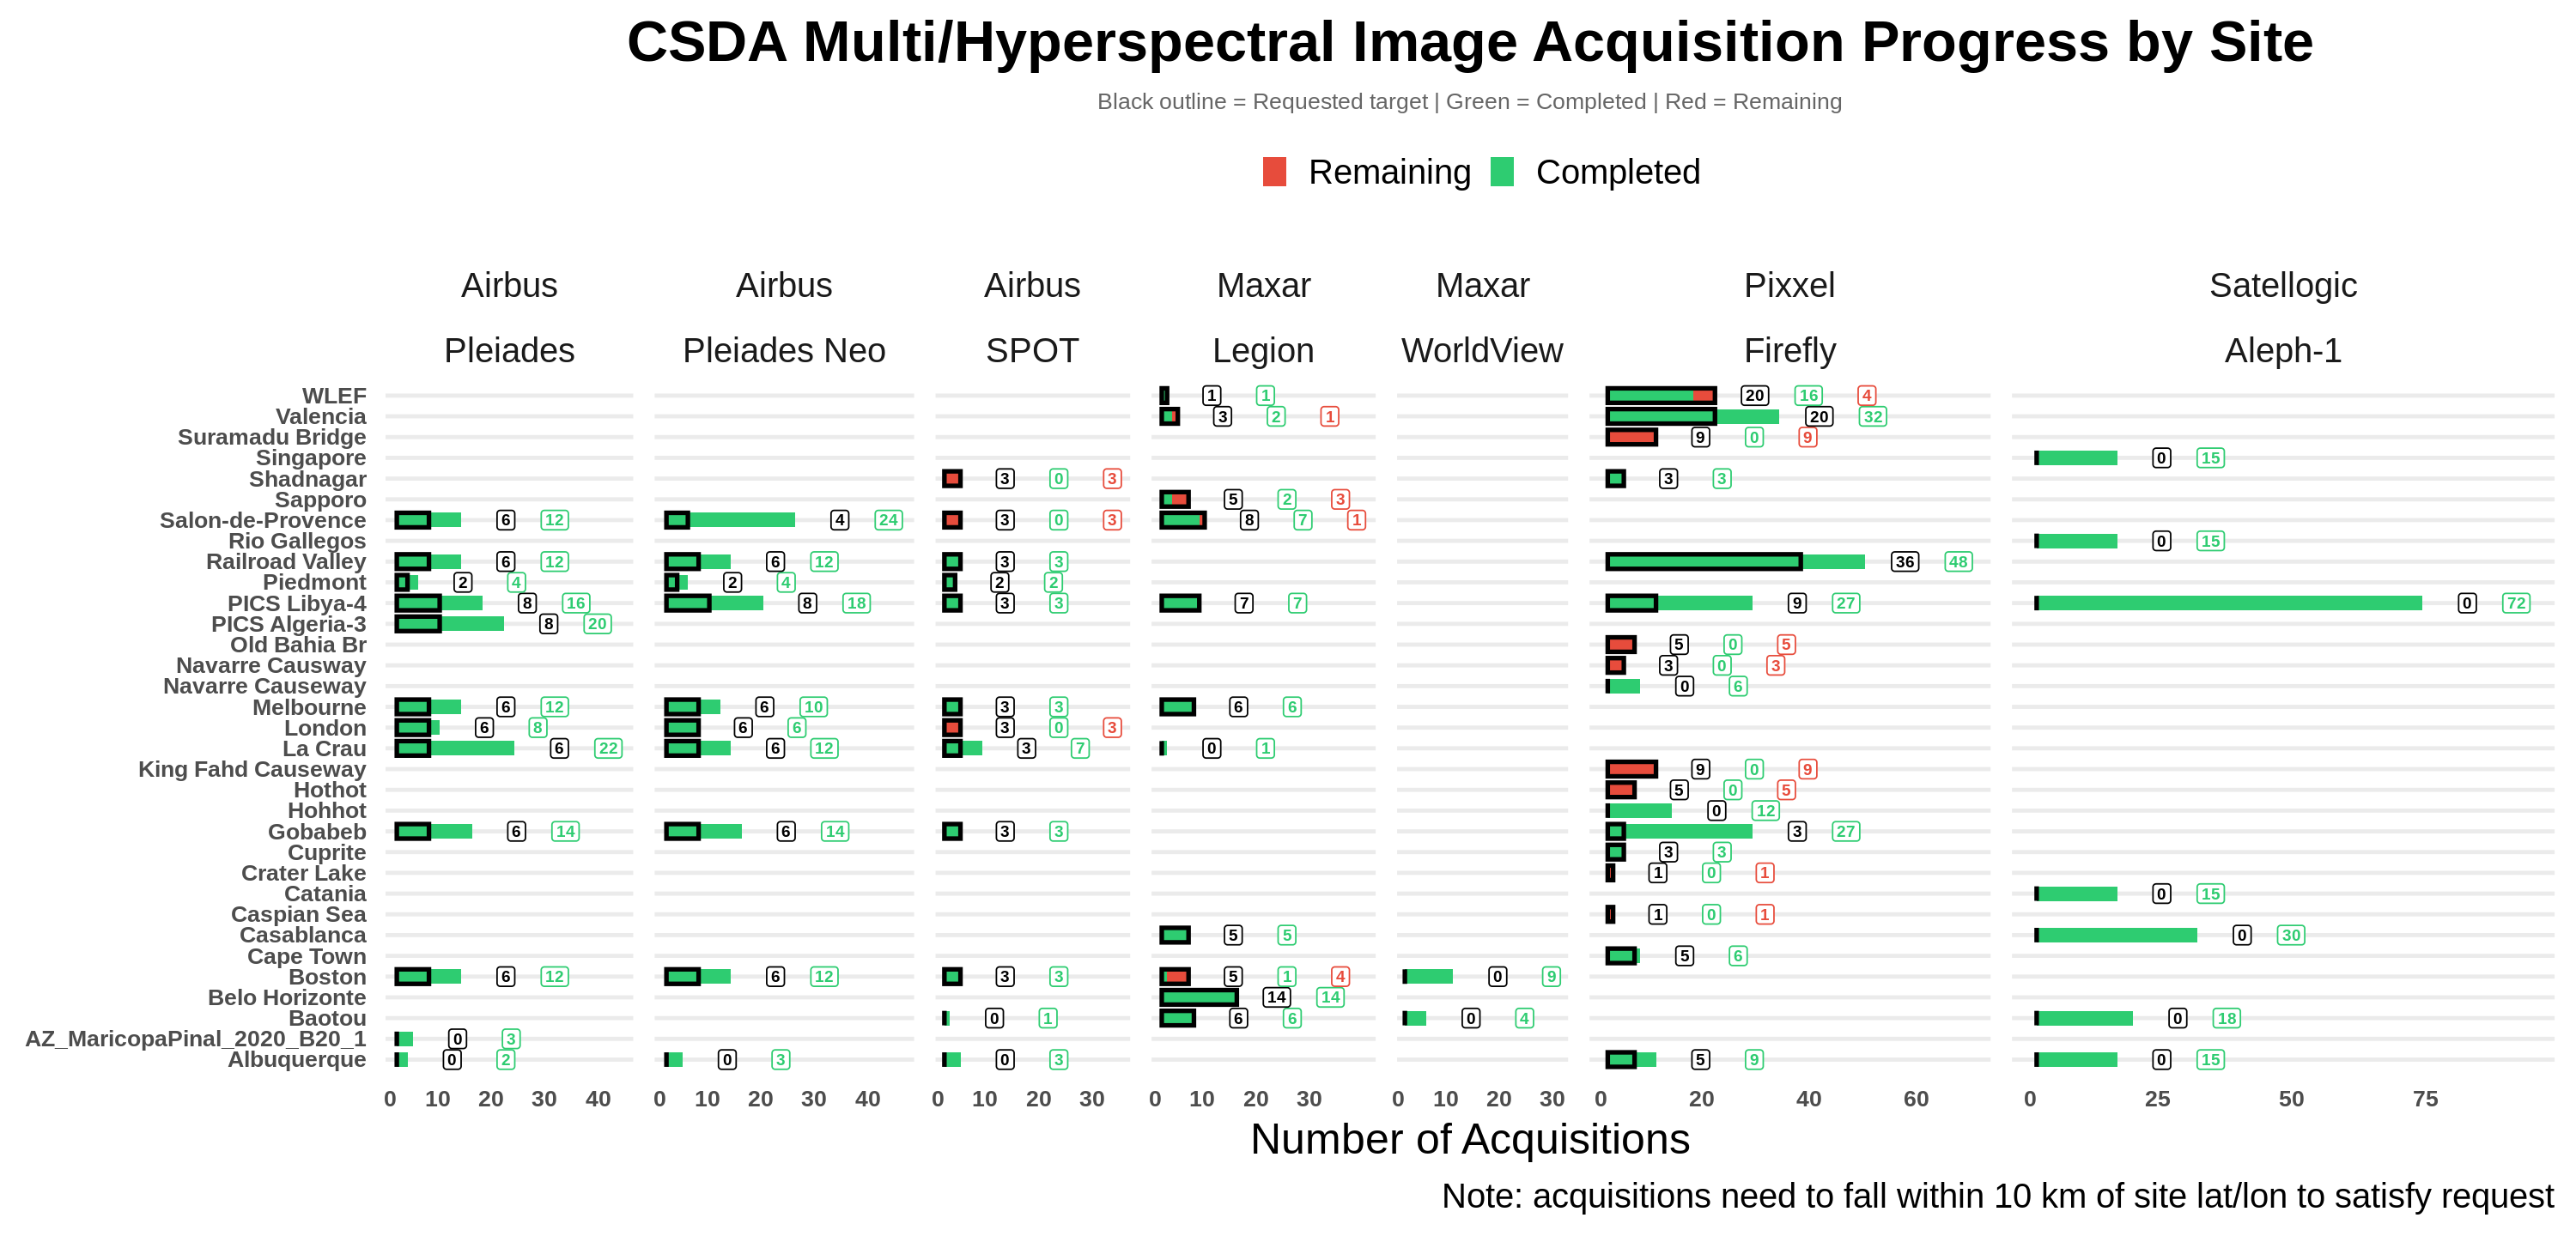

In [14]:
options(repr.plot.width = 25, repr.plot.height = 12)

p_progress_v2